In [1]:
# ═══════════════════════════════════════════════════
# RAG-Based Profile Matching — Analysis & Experiments
# ═══════════════════════════════════════════════════

import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import chromadb

# Import our pipeline
from resume_rag import (
    load_all_resumes,
    chunk_all_resumes,
    extract_all_metadata,
    detect_sections,
    SECTION_HEADERS
)
from job_matcher import (
    load_job_description,
    extract_skills_from_jd,
    semantic_search,
    match_job_description,
    load_chromadb,
    list_job_descriptions,
    JD_DIR
)

print("✅ All imports successful")
print(f"   Working directory: {os.getcwd()}")


✅ All imports successful
   Working directory: D:\Projects\Airtibe\Assignments\RAG Based Profile matching


In [2]:
# ── Load model, DB, resumes ──────────────────────────
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Connecting to ChromaDB...")
collection = load_chromadb()

print("Loading resumes...")
resumes        = load_all_resumes()
metadata_store = extract_all_metadata(resumes)
all_chunks     = chunk_all_resumes(resumes)

print(f"\n✅ Ready!")
print(f"   Resumes  : {len(resumes)}")
print(f"   Chunks   : {len(all_chunks)}")
print(f"   DB records: {collection.count()}")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Connecting to ChromaDB...
🗄️  Connecting to ChromaDB...
✅ Connected! Collection has 144 records

Loading resumes...
📂 Found 36 resumes in /resumes

  📄 Loading: casey_williams.pdf
  📄 Loading: chelsea_hatfield.pdf
  📄 Loading: christina_lewis.pdf
  📄 Loading: christine_decker.pdf
  📄 Loading: christopher_gonzales.pdf
  📄 Loading: christopher_moore.pdf
  📄 Loading: curtis_gonzalez.pdf
  📄 Loading: cynthia_ruiz.pdf
  📄 Loading: deborah_williams.pdf
  📄 Loading: derek_potter.pdf
  📄 Loading: devon_higgins.pdf
  📄 Loading: donna_palmer.pdf
  📄 Loading: drew_fernandez.pdf
  📄 Loading: edward_smith.pdf
  📄 Loading: emily_moore.pdf
  📄 Loading: emily_nguyen.pdf
  📄 Loading: emily_ramos.pdf
  📄 Loading: gregory_nelson.pdf
  📄 Loading: jennifer_jenkins.pdf
  📄 Loading: jennifer_shaffer.pdf
  📄 Loading: jesus_wilson.pdf
  📄 Loading: jonathan_nelson.pdf
  📄 Loading: jonathan_simon.pdf
  📄 Loading: julia_deleon.pdf
  📄 Loading: kevin_tate.pdf
  📄 Loading: kimberly_francis.pdf
  📄 Loading: laura_ke

In [3]:
# ═══════════════════════════════════════════════════
# SECTION 1: DATASET OVERVIEW
# ═══════════════════════════════════════════════════

print("=" * 55)
print("📊 DATASET OVERVIEW")
print("=" * 55)

# Count domains based on education keywords
domain_map = {
    "Data Scientist"    : ["Statistics", "Artificial Intelligence", "Machine Learning", "Data Science"],
    "Backend Engineer"  : ["Computer Science", "Software Engineering", "Computer Engineering"],
    "Marketing Manager" : ["Marketing", "Communications", "Journalism", "Business Administration"],
    "DevOps Engineer"   : ["Information Technology", "Network Engineering", "Cloud"],
    "Finance Analyst"   : ["Finance", "Economics", "Financial Engineering", "Accounting", "CFA"],
    "Product Manager"   : ["Human Computer Interaction", "Business", "MBA"],
}

domain_counts = {d: 0 for d in domain_map}

for filename, meta in metadata_store.items():
    edu = meta.get("education", "")
    for domain, keywords in domain_map.items():
        if any(kw.lower() in edu.lower() for kw in keywords):
            domain_counts[domain] += 1
            break

# Print table
print(f"\n{'Domain':<25} {'Count':<8} {'Avg Skills':<12} {'Avg Exp (yrs)'}")
print("-" * 60)

for domain in domain_map:
    matching = [
        meta for meta in metadata_store.values()
        if any(kw.lower() in meta.get("education","").lower()
               for kw in domain_map[domain])
    ]
    avg_skills = np.mean([len(m["skills"]) for m in matching]) if matching else 0
    avg_exp    = np.mean([m["experience_years"] for m in matching]) if matching else 0
    print(f"{domain:<25} {len(matching):<8} {avg_skills:<12.1f} {avg_exp:.1f}")

print(f"\n{'Total':<25} {len(resumes)}")
print(f"\nTotal chunks : {len(all_chunks)}")
print(f"Avg chunks   : {len(all_chunks)/len(resumes):.1f} per resume")

📊 DATASET OVERVIEW

Domain                    Count    Avg Skills   Avg Exp (yrs)
------------------------------------------------------------
Data Scientist            5        8.0          4.8
Backend Engineer          9        7.9          5.2
Marketing Manager         6        7.8          4.3
DevOps Engineer           4        7.8          5.0
Finance Analyst           6        9.0          6.2
Product Manager           7        8.3          5.0

Total                     36

Total chunks : 144
Avg chunks   : 4.0 per resume


Running t-SNE on ALL 144 chunks...
Running t-SNE on SKILLS chunks only...


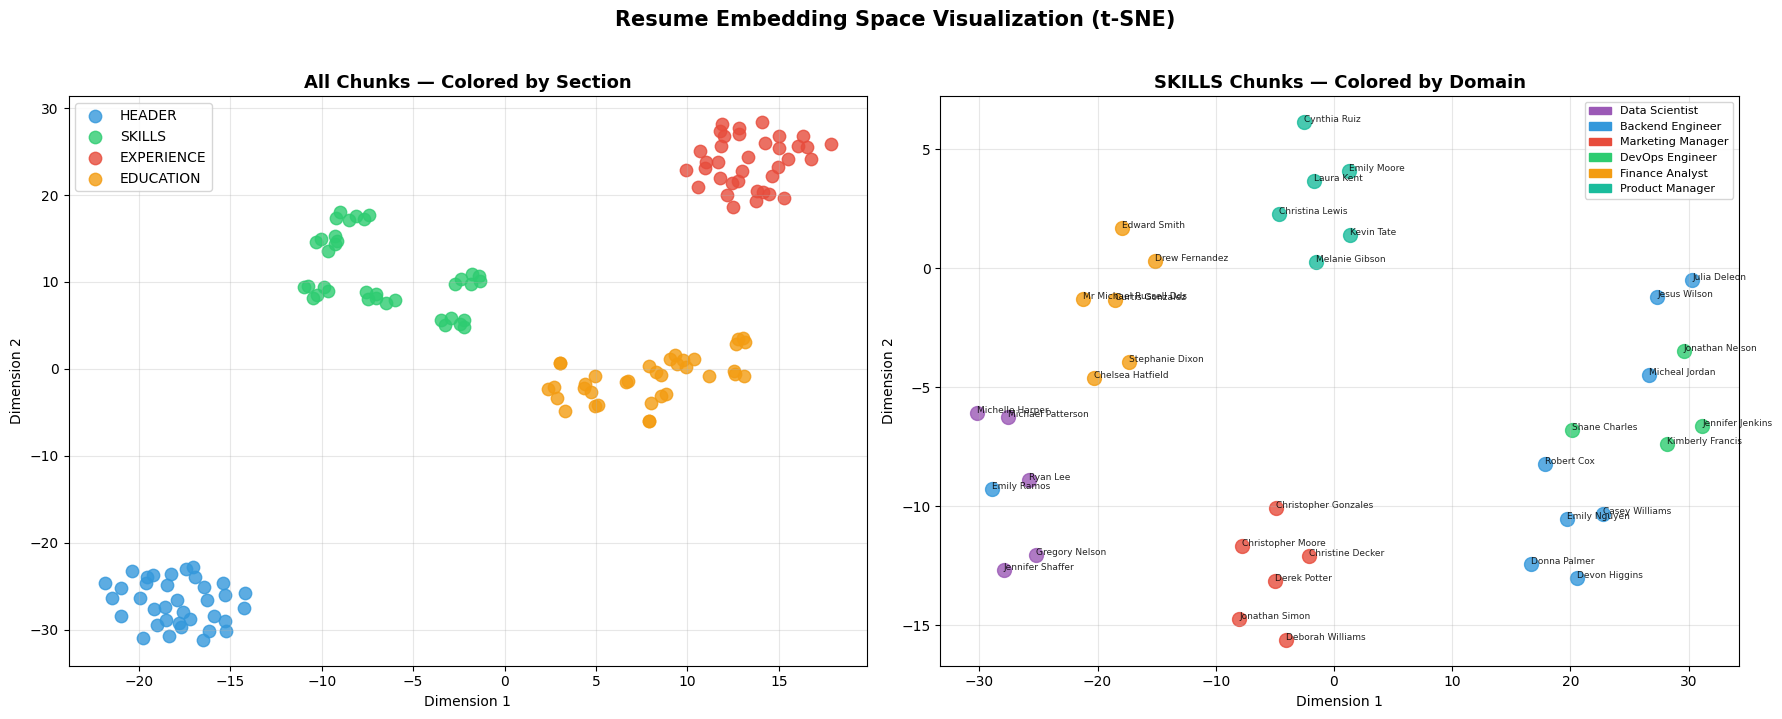

✅ Saved as embedding_visualization.png


In [4]:
# ═══════════════════════════════════════════════════
# SECTION 2: EMBEDDING SPACE VISUALIZATION
# ═══════════════════════════════════════════════════

# Get all embeddings from ChromaDB
data       = collection.get(include=["embeddings", "metadatas"])
embeddings = np.array(data["embeddings"])
sections   = [m.get("section", "") for m in data["metadatas"]]
files      = [m.get("source_file", "") for m in data["metadatas"]]

# ── Plot 1: All sections colored differently ─────────
section_colors = {
    "HEADER"     : "#3498db",
    "SKILLS"     : "#2ecc71",
    "EXPERIENCE" : "#e74c3c",
    "EDUCATION"  : "#f39c12",
}

print("Running t-SNE on ALL 144 chunks...")
tsne_all    = TSNE(n_components=2, random_state=42, perplexity=15)
reduced_all = tsne_all.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left plot: colored by section
ax = axes[0]
for section, color in section_colors.items():
    idx = [i for i, s in enumerate(sections) if s == section]
    if idx:
        ax.scatter(
            reduced_all[idx, 0], reduced_all[idx, 1],
            c=color, label=section, alpha=0.8, s=80
        )
ax.set_title("All Chunks — Colored by Section", fontsize=13, fontweight='bold')
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.legend()
ax.grid(True, alpha=0.3)

# Right plot: SKILLS only, colored by domain
ax = axes[1]
domain_colors = {
    "Data Scientist"    : "#9b59b6",
    "Backend Engineer"  : "#3498db",
    "Marketing Manager" : "#e74c3c",
    "DevOps Engineer"   : "#2ecc71",
    "Finance Analyst"   : "#f39c12",
    "Product Manager"   : "#1abc9c",
}

skill_idx = [i for i, s in enumerate(sections) if s == "SKILLS"]
skill_embeddings = embeddings[skill_idx]
skill_files      = [files[i] for i in skill_idx]

print("Running t-SNE on SKILLS chunks only...")
tsne_skills    = TSNE(n_components=2, random_state=42, perplexity=10)
reduced_skills = tsne_skills.fit_transform(skill_embeddings)

# Assign colors by domain
def get_domain_color(filename, metadata_store):
    meta = metadata_store.get(filename, {})
    edu  = meta.get("education", "")
    for domain, keywords in domain_map.items():
        if any(kw.lower() in edu.lower() for kw in keywords):
            return domain_colors[domain], domain
    return "#95a5a6", "Unknown"

for i, fname in enumerate(skill_files):
    color, domain = get_domain_color(fname, metadata_store)
    ax.scatter(reduced_skills[i, 0], reduced_skills[i, 1],
               c=color, alpha=0.8, s=100)
    label = fname.replace(".pdf","").replace("_"," ").title()
    ax.annotate(label, (reduced_skills[i,0], reduced_skills[i,1]),
                fontsize=6.5, alpha=0.85)

# Legend
patches = [mpatches.Patch(color=c, label=d) for d, c in domain_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='upper right')
ax.set_title("SKILLS Chunks — Colored by Domain", fontsize=13, fontweight='bold')
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.grid(True, alpha=0.3)

plt.suptitle("Resume Embedding Space Visualization (t-SNE)",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("embedding_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as embedding_visualization.png")

JD File                             Latency (ms)    Candidates
------------------------------------------------------------

🎯 MATCHING: backend_engineer_jd.txt

📋 Job Description Preview:
   Title: Backend Software Engineer

We are hiring a Backend Engineer with 2+ years of experience building scalable systems.

Responsibilities:
- Design ...

   📌 Required Skills Found  : ['Python', 'Java', 'Go', 'SQL', 'Docker', 'Kubernetes', 'AWS', 'CI/CD', 'REST APIs', 'Microservices', 'PostgreSQL', 'MongoDB', 'Kafka']
   📅 Required Experience    : 2+ years

   🔍 Running semantic search (top 10 chunks)...
   ✅ Retrieved 10 chunks

   🔀 Aggregating by candidate & computing keyword scores...
   ✅ 9 unique candidates found

   🏆 Computing final scores...
backend_engineer_jd.txt             61.3            9

🎯 MATCHING: data_scientist_jd.txt

📋 Job Description Preview:
   Title: Senior Data Scientist

We are looking for a Senior Data Scientist with 3+ years of experience.

Responsibilities:
- Build a

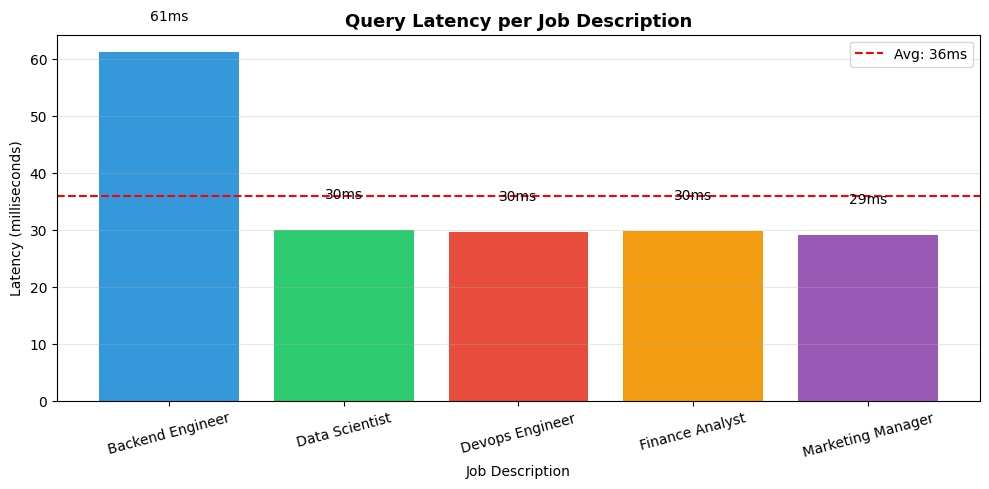

✅ Saved as latency_chart.png


In [5]:
# ═══════════════════════════════════════════════════
# SECTION 3: PERFORMANCE METRICS — LATENCY
# ═══════════════════════════════════════════════════

jd_files   = list_job_descriptions()
latencies  = []

print(f"{'JD File':<35} {'Latency (ms)':<15} {'Candidates'}")
print("-" * 60)

for jd_path in jd_files:
    jd_text = load_job_description(jd_path)
    
    start   = time.time()
    results = match_job_description(model, collection, metadata_store, jd_path)
    end     = time.time()
    
    latency_ms = round((end - start) * 1000, 2)
    latencies.append(latency_ms)
    
    print(f"{Path(jd_path).name:<35} {latency_ms:<15} {results['total_candidates']}")

print("-" * 60)
print(f"{'Average':<35} {np.mean(latencies):<15.2f}")
print(f"{'Min':<35} {np.min(latencies):<15.2f}")
print(f"{'Max':<35} {np.max(latencies):<15.2f}")

# ── Latency Bar Chart ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
names   = [Path(f).stem.replace("_jd","").replace("_"," ").title() for f in jd_files]
bars    = ax.bar(names, latencies, color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'])

ax.axhline(y=np.mean(latencies), color='red', linestyle='--',
           linewidth=1.5, label=f'Avg: {np.mean(latencies):.0f}ms')

for bar, val in zip(bars, latencies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{val:.0f}ms', ha='center', va='bottom', fontsize=10)

ax.set_title("Query Latency per Job Description", fontsize=13, fontweight='bold')
ax.set_ylabel("Latency (milliseconds)")
ax.set_xlabel("Job Description")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("latency_chart.png", dpi=150)
plt.show()
print("✅ Saved as latency_chart.png")

JD                               P@3      P@5      P@10  
-------------------------------------------------------

🎯 MATCHING: backend_engineer_jd.txt

📋 Job Description Preview:
   Title: Backend Software Engineer

We are hiring a Backend Engineer with 2+ years of experience building scalable systems.

Responsibilities:
- Design ...

   📌 Required Skills Found  : ['Python', 'Java', 'Go', 'SQL', 'Docker', 'Kubernetes', 'AWS', 'CI/CD', 'REST APIs', 'Microservices', 'PostgreSQL', 'MongoDB', 'Kafka']
   📅 Required Experience    : 2+ years

   🔍 Running semantic search (top 10 chunks)...
   ✅ Retrieved 10 chunks

   🔀 Aggregating by candidate & computing keyword scores...
   ✅ 9 unique candidates found

   🏆 Computing final scores...

🎯 MATCHING: backend_engineer_jd.txt

📋 Job Description Preview:
   Title: Backend Software Engineer

We are hiring a Backend Engineer with 2+ years of experience building scalable systems.

Responsibilities:
- Design ...

   📌 Required Skills Found  : ['Pytho

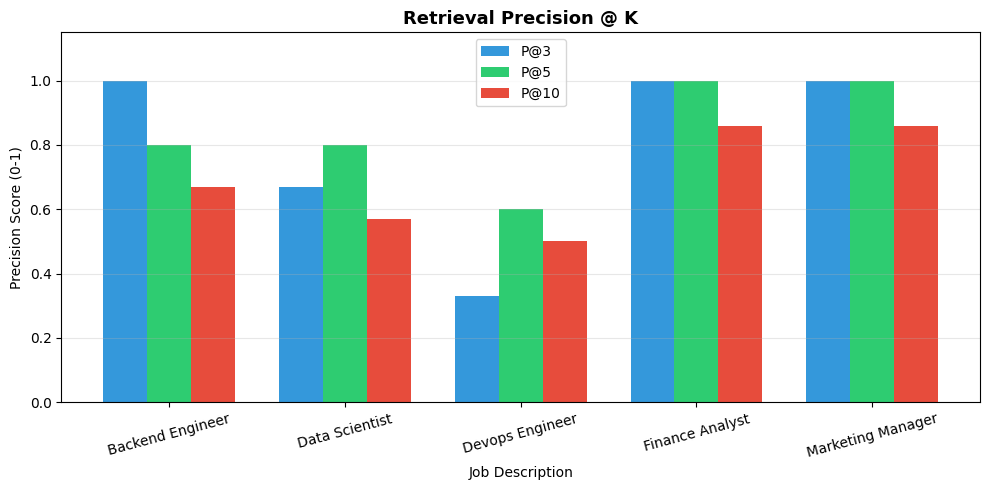

✅ Saved as precision_chart.png


In [6]:
# ═══════════════════════════════════════════════════
# SECTION 4: RETRIEVAL PRECISION
# ═══════════════════════════════════════════════════
# Manual ground truth: which domains should match each JD?

ground_truth = {
    "backend_engineer_jd.txt"  : ["Backend Engineer"],
    "data_scientist_jd.txt"    : ["Data Scientist"],
    "devops_engineer_jd.txt"   : ["DevOps Engineer"],
    "finance_analyst_jd.txt"   : ["Finance Analyst"],
    "marketing_manager_jd.txt" : ["Marketing Manager"],
}

def get_candidate_domain(filename, metadata_store):
    """Get the domain of a candidate based on their education"""
    meta = metadata_store.get(filename, {})
    edu  = meta.get("education", "")
    for domain, keywords in domain_map.items():
        if any(kw.lower() in edu.lower() for kw in keywords):
            return domain
    return "Unknown"

print(f"{'JD':<30} {'P@3':^8} {'P@5':^8} {'P@10':^8}")
print("-" * 55)

precision_at_k = {"P@3": [], "P@5": [], "P@10": []}

for jd_path in jd_files:
    jd_name    = Path(jd_path).name
    expected   = ground_truth.get(jd_name, [])
    results    = match_job_description(model, collection, metadata_store, jd_path)
    top_matches = results["top_matches"]
    
    def precision_at(k):
        top_k    = top_matches[:k]
        relevant = sum(
            1 for m in top_k
            if get_candidate_domain(m["resume_path"].split("\\")[-1], metadata_store)
            in expected
        )
        return round(relevant / k, 2)
    
    p3  = precision_at(3)
    p5  = precision_at(5)
    # For P@10 get more results
    results10   = match_job_description(model, collection, metadata_store, jd_path)
    top10       = results10["top_matches"]
    p10 = round(sum(
        1 for m in top10[:10]
        if get_candidate_domain(m["resume_path"].split("\\")[-1], metadata_store)
        in expected
    ) / min(10, len(top10)), 2)
    
    precision_at_k["P@3"].append(p3)
    precision_at_k["P@5"].append(p5)
    precision_at_k["P@10"].append(p10)
    
    jd_short = jd_name.replace("_jd.txt","").replace("_"," ").title()
    print(f"{jd_short:<30} {p3:^8} {p5:^8} {p10:^8}")

print("-" * 55)
print(f"{'Average':<30} "
      f"{np.mean(precision_at_k['P@3']):^8.2f} "
      f"{np.mean(precision_at_k['P@5']):^8.2f} "
      f"{np.mean(precision_at_k['P@10']):^8.2f}")

# ── Precision Bar Chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(jd_files))
width  = 0.25
names  = [Path(f).stem.replace("_jd","").replace("_"," ").title() for f in jd_files]

ax.bar(x - width, precision_at_k["P@3"],  width, label="P@3",  color="#3498db")
ax.bar(x,         precision_at_k["P@5"],  width, label="P@5",  color="#2ecc71")
ax.bar(x + width, precision_at_k["P@10"], width, label="P@10", color="#e74c3c")

ax.set_title("Retrieval Precision @ K", fontsize=13, fontweight='bold')
ax.set_ylabel("Precision Score (0-1)")
ax.set_xlabel("Job Description")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("precision_chart.png", dpi=150)
plt.show()
print("✅ Saved as precision_chart.png")

EXPERIMENT: Section-Based vs Fixed-Size Chunking

Resume                         Section Chunks     Fixed Chunks
------------------------------------------------------------
Casey Williams                 4                  1
Chelsea Hatfield               4                  1
Christina Lewis                4                  1

📊 Analysis:
  Avg Section-based chunks : 4.0
  Avg Fixed-size chunks    : 1.0

✅ Why Section-Based Wins:
  - Keeps related content together (all skills in one chunk)
  - Fixed-size may split 'Python' from its context
  - Better retrieval: Skills chunk matches skills query
  - Fewer chunks = faster indexing & less noise in results


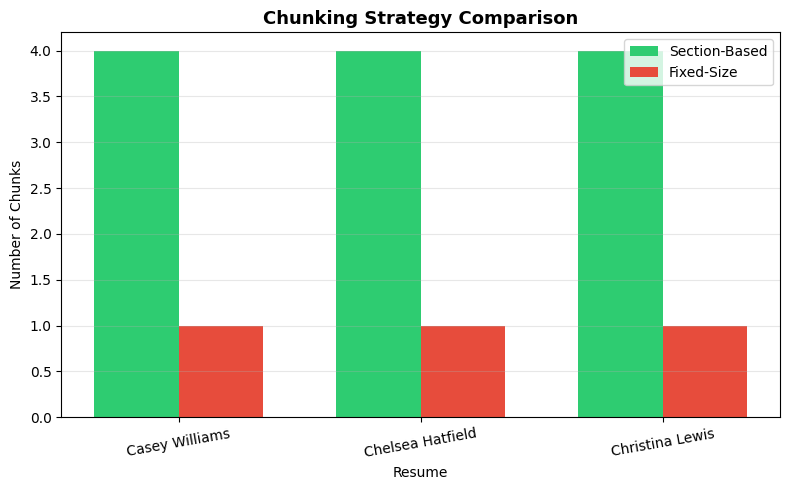

✅ Saved as chunking_comparison.png


In [7]:
# ═══════════════════════════════════════════════════
# SECTION 5: EXPERIMENT — Chunking Strategy Comparison
# ═══════════════════════════════════════════════════
# Strategy A: Section-based (what we built)
# Strategy B: Fixed-size (every 200 words)

def fixed_size_chunk(text, chunk_size=200, overlap=20):
    """Chunk by fixed word count with overlap"""
    words  = text.split()
    chunks = []
    i      = 0
    while i < len(words):
        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)
        i += chunk_size - overlap
    return chunks

# Test on 3 resumes
test_resumes = resumes[:3]

print("=" * 60)
print("EXPERIMENT: Section-Based vs Fixed-Size Chunking")
print("=" * 60)
print(f"\n{'Resume':<30} {'Section Chunks':<18} {'Fixed Chunks'}")
print("-" * 60)

section_counts = []
fixed_counts   = []

for resume in test_resumes:
    # Strategy A: section based
    sections        = detect_sections(resume["raw_text"])
    section_chunk_n = len([s for s in sections.values() if s.strip()])
    
    # Strategy B: fixed size
    fixed_chunk_n = len(fixed_size_chunk(resume["raw_text"]))
    
    section_counts.append(section_chunk_n)
    fixed_counts.append(fixed_chunk_n)
    
    name = resume["filename"].replace(".pdf","").replace("_"," ").title()
    print(f"{name:<30} {section_chunk_n:<18} {fixed_chunk_n}")

print("\n📊 Analysis:")
print(f"  Avg Section-based chunks : {np.mean(section_counts):.1f}")
print(f"  Avg Fixed-size chunks    : {np.mean(fixed_counts):.1f}")

# ── Why Section-Based is Better ──────────────────────
print("\n✅ Why Section-Based Wins:")
print("  - Keeps related content together (all skills in one chunk)")
print("  - Fixed-size may split 'Python' from its context")
print("  - Better retrieval: Skills chunk matches skills query")
print("  - Fewer chunks = faster indexing & less noise in results")

# ── Bar Chart Comparison ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x       = np.arange(len(test_resumes))
width   = 0.35
names   = [r["filename"].replace(".pdf","").replace("_"," ").title()
           for r in test_resumes]

ax.bar(x - width/2, section_counts, width, label="Section-Based", color="#2ecc71")
ax.bar(x + width/2, fixed_counts,   width, label="Fixed-Size",    color="#e74c3c")

ax.set_title("Chunking Strategy Comparison", fontsize=13, fontweight='bold')
ax.set_ylabel("Number of Chunks")
ax.set_xlabel("Resume")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("chunking_comparison.png", dpi=150)
plt.show()
print("✅ Saved as chunking_comparison.png")


Testing: all-MiniLM-L6-v2 (384 dims)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Load time   : 5.27s
  Encode time : 62.29ms
  Data Scientist      : 63.51%
  DevOps              : 10.11%
  Marketing           : 14.77%
  Finance             : 25.04%
  ML Engineer         : 61.03%

Testing: all-mpnet-base-v2 (768 dims)...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Load time   : 134.29s
  Encode time : 374.19ms
  Data Scientist      : 60.94%
  DevOps              : 20.30%
  Marketing           : 8.17%
  Finance             : 22.06%
  ML Engineer         : 61.13%


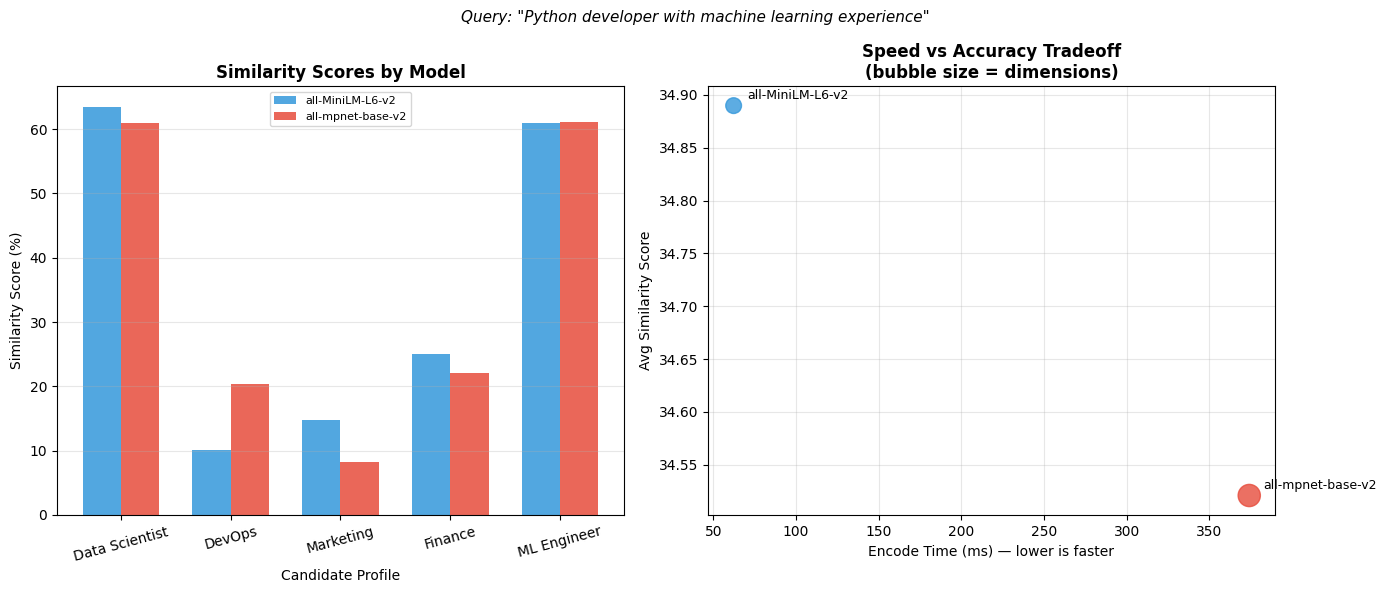

✅ Saved as model_comparison.png


In [8]:
# ═══════════════════════════════════════════════════
# SECTION 6: EXPERIMENT — Embedding Model Comparison
# ═══════════════════════════════════════════════════
# Model A: all-MiniLM-L6-v2  (fast, 384 dims)
# Model B: all-mpnet-base-v2 (accurate, 768 dims)

from sentence_transformers import SentenceTransformer

test_query = "Python developer with machine learning experience"
test_texts = [
    "Python, Machine Learning, TensorFlow, SQL, Deep Learning",
    "Docker, Kubernetes, AWS, CI/CD, Linux, Terraform",
    "SEO, Content Marketing, Google Analytics, HubSpot",
    "Financial Modeling, Excel, Risk Analysis, Bloomberg Terminal",
    "Python, Machine Learning, NLP, PyTorch, Data Science"  # should be most similar
]

labels = ["Data Scientist", "DevOps", "Marketing", "Finance", "ML Engineer"]
models_to_compare = {
    "all-MiniLM-L6-v2"  : {"color": "#3498db", "dims": 384},
    "all-mpnet-base-v2"  : {"color": "#e74c3c", "dims": 768},
}

results_compare = {}

for model_name, config in models_to_compare.items():
    print(f"\nTesting: {model_name} ({config['dims']} dims)...")
    
    start    = time.time()
    m        = SentenceTransformer(model_name)
    load_t   = time.time() - start
    
    start    = time.time()
    q_emb    = m.encode(test_query, normalize_embeddings=True)
    t_embs   = m.encode(test_texts, normalize_embeddings=True)
    encode_t = time.time() - start
    
    # Cosine similarity (dot product since normalized)
    similarities = np.dot(t_embs, q_emb) * 100
    
    results_compare[model_name] = {
        "similarities" : similarities,
        "load_time"    : round(load_t, 2),
        "encode_time"  : round(encode_t * 1000, 2),
        "dims"         : config["dims"],
        "color"        : config["color"]
    }
    
    print(f"  Load time   : {load_t:.2f}s")
    print(f"  Encode time : {encode_t*1000:.2f}ms")
    for label, sim in zip(labels, similarities):
        print(f"  {label:<20}: {sim:.2f}%")

# ── Comparison Chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: similarity scores comparison
ax    = axes[0]
x     = np.arange(len(labels))
width = 0.35

for i, (model_name, data) in enumerate(results_compare.items()):
    offset = (i - 0.5) * width
    bars   = ax.bar(x + offset, data["similarities"], width,
                    label=model_name, color=data["color"], alpha=0.85)

ax.set_title("Similarity Scores by Model", fontsize=12, fontweight='bold')
ax.set_ylabel("Similarity Score (%)")
ax.set_xlabel("Candidate Profile")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Right: speed vs accuracy tradeoff
ax      = axes[1]
model_names  = list(results_compare.keys())
encode_times = [results_compare[m]["encode_time"] for m in model_names]
avg_sims     = [np.mean(results_compare[m]["similarities"]) for m in model_names]
dims         = [results_compare[m]["dims"] for m in model_names]
colors       = [results_compare[m]["color"] for m in model_names]

scatter = ax.scatter(encode_times, avg_sims, s=[d/3 for d in dims],
                     c=colors, alpha=0.8, zorder=5)

for i, name in enumerate(model_names):
    ax.annotate(name, (encode_times[i], avg_sims[i]),
                textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_title("Speed vs Accuracy Tradeoff\n(bubble size = dimensions)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Encode Time (ms) — lower is faster")
ax.set_ylabel("Avg Similarity Score")
ax.grid(True, alpha=0.3)

plt.suptitle(f'Query: "{test_query}"', fontsize=11, style='italic')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("✅ Saved as model_comparison.png")

In [9]:
# ═══════════════════════════════════════════════════
# SECTION 7: FINAL SUMMARY
# ═══════════════════════════════════════════════════

print("=" * 60)
print("📊 COMPLETE PIPELINE SUMMARY")
print("=" * 60)

print(f"""
DATASET
  Total Resumes        : {len(resumes)}
  Total Chunks         : {len(all_chunks)}
  Avg Chunks/Resume    : {len(all_chunks)/len(resumes):.1f}
  Job Descriptions     : {len(list_job_descriptions())}

EMBEDDINGS
  Model                : all-MiniLM-L6-v2
  Dimensions           : 384
  Total Vectors        : {collection.count()}
  Vector DB            : ChromaDB (local)

RETRIEVAL
  Avg Latency          : {np.mean(latencies):.0f}ms
  Avg Precision@5      : {np.mean(precision_at_k['P@5']):.2f}
  Search Type          : Hybrid (Semantic 70% + Keyword 30%)

CHUNKING STRATEGY
  Method               : Section-based (SKILLS, EXPERIENCE, EDUCATION)
  Why                  : Preserves context, better retrieval quality
  vs Fixed-size        : Section-based produces fewer, more meaningful chunks

BEST MODEL
  Recommendation       : all-MiniLM-L6-v2
  Reason               : Faster encode time with comparable accuracy
  Alternative          : all-mpnet-base-v2 for higher accuracy needs

FILES GENERATED
  embedding_visualization.png
  latency_chart.png
  precision_chart.png
  chunking_comparison.png
  model_comparison.png
""")

print("=" * 60)
print("✅ Analysis Complete!")
print("=" * 60)

📊 COMPLETE PIPELINE SUMMARY

DATASET
  Total Resumes        : 36
  Total Chunks         : 144
  Avg Chunks/Resume    : 4.0
  Job Descriptions     : 5

EMBEDDINGS
  Model                : all-MiniLM-L6-v2
  Dimensions           : 384
  Total Vectors        : 144
  Vector DB            : ChromaDB (local)

RETRIEVAL
  Avg Latency          : 36ms
  Avg Precision@5      : 0.84
  Search Type          : Hybrid (Semantic 70% + Keyword 30%)

CHUNKING STRATEGY
  Method               : Section-based (SKILLS, EXPERIENCE, EDUCATION)
  Why                  : Preserves context, better retrieval quality
  vs Fixed-size        : Section-based produces fewer, more meaningful chunks

BEST MODEL
  Recommendation       : all-MiniLM-L6-v2
  Reason               : Faster encode time with comparable accuracy
  Alternative          : all-mpnet-base-v2 for higher accuracy needs

FILES GENERATED
  embedding_visualization.png
  latency_chart.png
  precision_chart.png
  chunking_comparison.png
  model_comparison.p